In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd

In [3]:
FINAL_MODEL_PATH = r"C:\Users\hp\OneDrive\Desktop\DeepVision-Traffic-Sign-Recognition\model\model1.keras"
final_model = tf.keras.models.load_model(FINAL_MODEL_PATH)
print("Model loaded successfully")

Model loaded successfully


In [4]:
import os

DATA_DIR = r"C:\Users\hp\OneDrive\Desktop\DeepVision-Traffic-Sign-Recognition\Data"
print("Data directory exists:", os.path.exists(DATA_DIR))

Data directory exists: True


In [5]:
for layer in final_model.layers:
    print(layer.name, layer.__class__.__name__)

sequential Sequential
conv2d Conv2D
max_pooling2d MaxPooling2D
conv2d_1 Conv2D
max_pooling2d_1 MaxPooling2D
conv2d_2 Conv2D
max_pooling2d_2 MaxPooling2D
flatten Flatten
dense Dense
dropout Dropout
dense_1 Dense


In [6]:
import os

TEST_DIR = r"C:\Users\hp\OneDrive\Desktop\DeepVision-Traffic-Sign-Recognition\Data\Test"
test_files = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))])
print("Number of test images:", len(test_files))
print("First image:", test_files[0])

Number of test images: 12630
First image: 00000.png


In [7]:
test_image_path = os.path.join(TEST_DIR,test_files[0])
print("Image:", test_image_path)

Image: C:\Users\hp\OneDrive\Desktop\DeepVision-Traffic-Sign-Recognition\Data\Test\00000.png


In [8]:
TEST_META_PATH = r"C:\Users\hp\OneDrive\Desktop\DeepVision-Traffic-Sign-Recognition\Data\Test.csv"
test_meta = pd.read_csv(TEST_META_PATH)
print(test_meta.head())
print(test_meta.columns.tolist())

   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId            Path
0     53      54       6       5      48      49       16  Test/00000.png
1     42      45       5       5      36      40        1  Test/00001.png
2     48      52       6       6      43      47       38  Test/00002.png
3     27      29       5       5      22      24       33  Test/00003.png
4     60      57       5       5      55      52       11  Test/00004.png
['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']


In [9]:
test_image_path = os.path.join(DATA_DIR,test_meta.iloc[0]["Path"])
true_class = int(test_meta.iloc[0]["ClassId"])
print("Image:", test_image_path)
print("True class:", true_class)

Image: C:\Users\hp\OneDrive\Desktop\DeepVision-Traffic-Sign-Recognition\Data\Test/00000.png
True class: 16


In [10]:
test_image_path = os.path.join(DATA_DIR,test_meta.iloc[0]["Path"])
true_class = int(test_meta.iloc[0]["ClassId"])
print("Image:", test_image_path)
print("True class:", true_class)
print("Image exists:", os.path.exists(test_image_path))

Image: C:\Users\hp\OneDrive\Desktop\DeepVision-Traffic-Sign-Recognition\Data\Test/00000.png
True class: 16
Image exists: True


In [11]:
img = tf.keras.utils.load_img(test_image_path,target_size=(64, 64))
img_array = tf.keras.utils.img_to_array(img)
img_array = img_array / 255.0
img_batch = np.expand_dims(img_array,axis=0)
print("Input shape:", img_batch.shape)

Input shape: (1, 64, 64, 3)


In [12]:
# Build/call the loaded model once
_ = final_model(img_batch, training=False)
print("Model called successfully")
print("Model input shape:", final_model.input_shape)
print("Model output shape:", final_model.output_shape)

Model called successfully
Model input shape: (None, 64, 64, 3)
Model output shape: (None, 43)


In [13]:
last_conv_layer = None
for layer in reversed(final_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer
        break
print("Last convolutional layer:", last_conv_layer.name)

Last convolutional layer: conv2d_2


In [19]:
def make_gradcam_heatmap(img_array, model, target_layer_name):
    with tf.GradientTape() as tape:
        x = img_array
        target_output = None
        # Manually pass through the model
        for layer in model.layers:
            x = layer(x, training=False)
            if layer.name == target_layer_name:
                target_output = x
        predictions = x
        predicted_class = tf.argmax(predictions[0])
        class_score = predictions[0, predicted_class]
    # Gradients of predicted class
    grads = tape.gradient(class_score,target_output)
    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads,axis=(0, 1))
    # Remove batch dimension
    conv_output = target_output[0]
    # Weight feature maps
    heatmap = tf.reduce_sum(conv_output * pooled_grads,axis=-1)
    # ReLU
    heatmap = tf.maximum(heatmap,0)
    # Normalize
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return (heatmap.numpy(),int(predicted_class.numpy()))

In [20]:
heatmap, predicted_class = make_gradcam_heatmap(img_batch,final_model, "conv2d_2")
print("True class:", true_class)
print("Predicted class:", predicted_class)
print("Heatmap shape:", heatmap.shape)

True class: 16
Predicted class: 16
Heatmap shape: (12, 12)


In [22]:
original = cv2.imread(test_image_path)
original = cv2.cvtColor(original,cv2.COLOR_BGR2RGB)
original = cv2.resize(original,(64, 64))
heatmap_resized = cv2.resize(heatmap,(64, 64))
heatmap_uint8 = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_uint8,cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color,cv2.COLOR_BGR2RGB)
superimposed = cv2.addWeighted(original,0.6,heatmap_color,0.4,0)

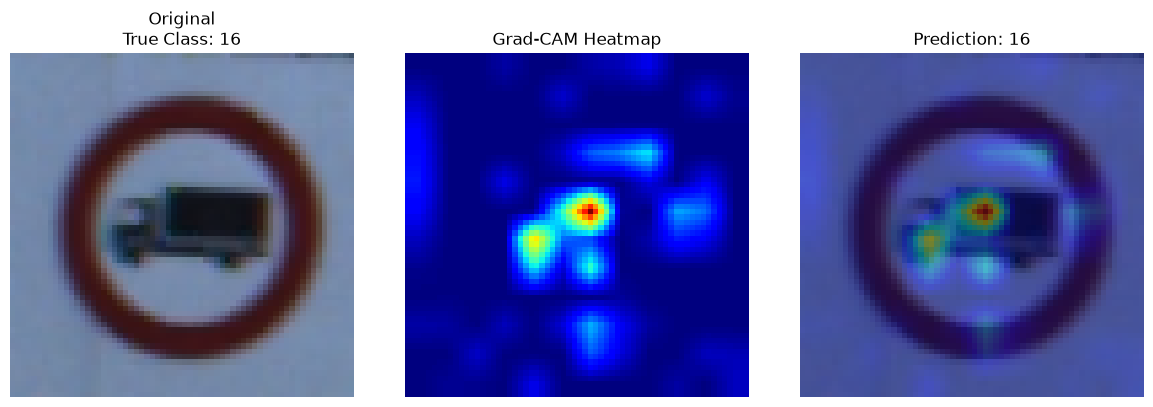

In [23]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title(f"Original\nTrue Class: {true_class}")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(superimposed)
plt.title(f"Prediction: {predicted_class}")
plt.axis("off")
plt.tight_layout()
plt.show()